In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load cleaned dataset
df = pd.read_parquet("cfpb_clean.parquet")
print(df.shape)
df.head()
print(df.info())

(708603, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 708603 entries, 0 to 1416887
Data columns (total 7 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Consumer complaint narrative  708603 non-null  object
 1   label                         708603 non-null  object
 2   Product                       708603 non-null  object
 3   State                         706841 non-null  object
 4   Issue                         708603 non-null  object
 5   Sub-issue                     679234 non-null  object
 6   Date received                 708603 non-null  object
dtypes: object(7)
memory usage: 43.2+ MB
None


In [2]:
#Missing values check
df.isna().sum().sort_values(ascending=False)

Sub-issue                       29369
State                            1762
Consumer complaint narrative        0
label                               0
Product                             0
Issue                               0
Date received                       0
dtype: int64

In [3]:
#Quick preview of label distribution
print(df['label'].value_counts())

label
credit_issue         506801
debt_fraud           103618
scam                  46105
fraud                 24958
transaction_issue     22238
security_issue         4411
identity_theft          472
Name: count, dtype: int64


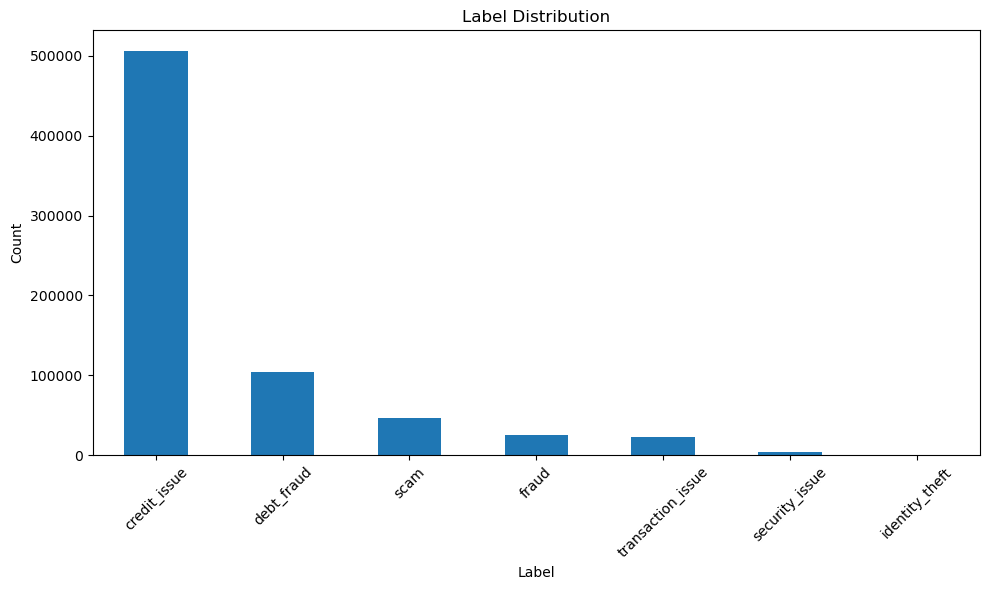

In [4]:
#Plot label distribution
df['label'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
#Product distribution
print(df['Product'].value_counts().head(15))

Product
Credit reporting or other personal consumer reports    502930
Debt collection                                        149723
Credit card                                             26414
Money transfer, virtual currency, or money service      24958
Student loan                                             2364
Mortgage                                                 1819
Checking or savings account                               395
Name: count, dtype: int64


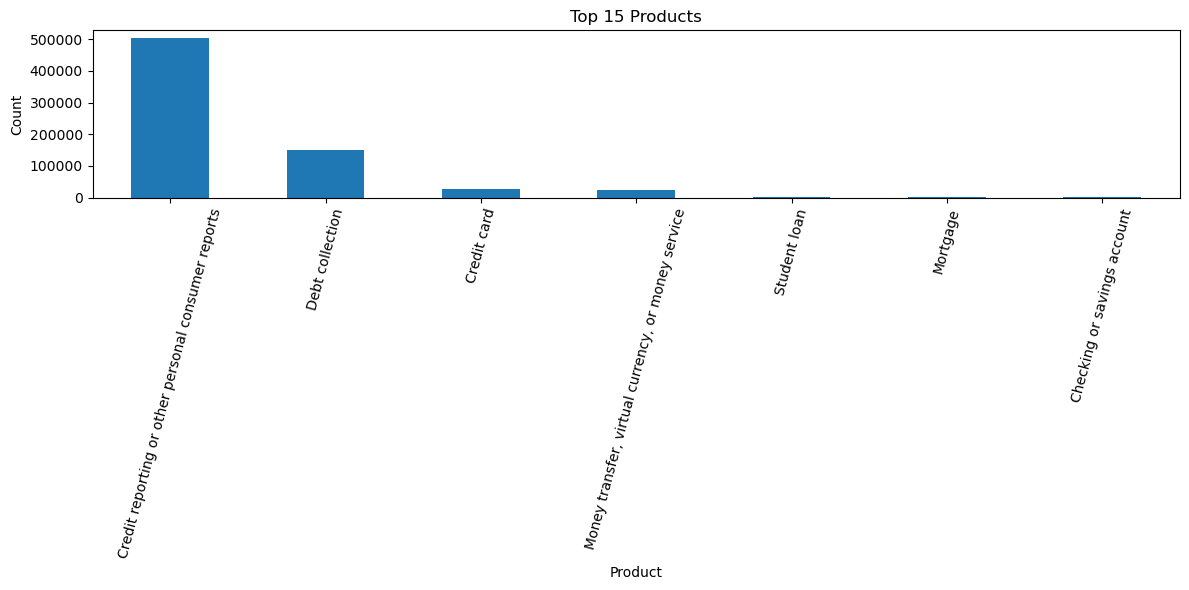

In [6]:
#Plot top products
df['Product'].value_counts().head(15).plot(kind='bar', figsize=(12, 6))
plt.title("Top 15 Products")
plt.xlabel("Product")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [7]:
#Top states
print(df['State'].value_counts().head(15))

State
TX    92679
FL    91318
CA    73460
GA    61747
NY    40746
IL    29378
PA    26962
NC    25039
NJ    23482
MI    18258
OH    17911
MD    15011
VA    14957
SC    14811
AZ    13809
Name: count, dtype: int64


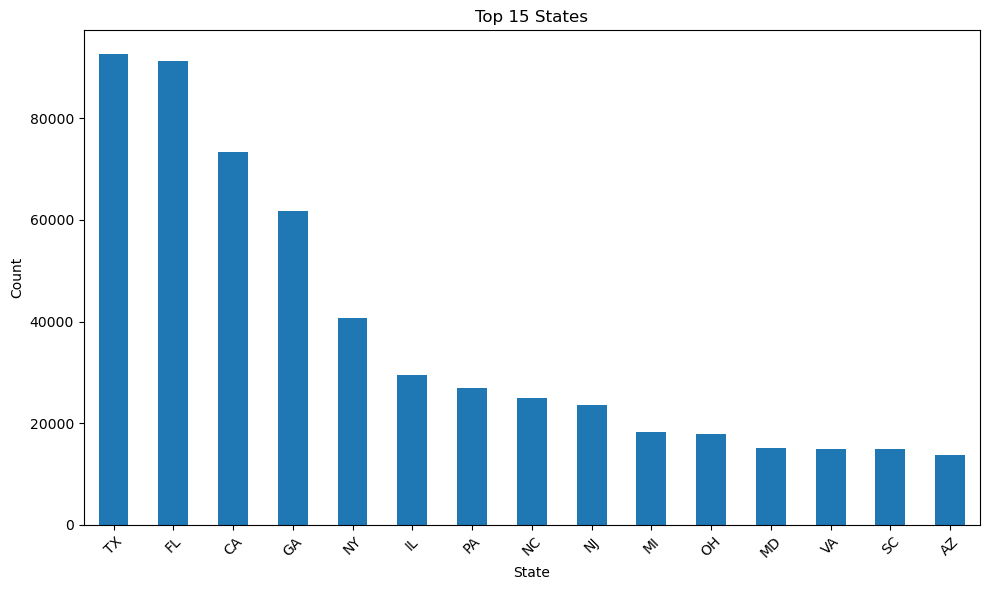

In [8]:
#Plot top states
df['State'].value_counts().head(15).plot(kind='bar', figsize=(10, 6))
plt.title("Top 15 States")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
#Top issues
print(df['Issue'].value_counts().head(15))

Issue
Incorrect information on your report                      321603
Improper use of your report                               185198
Attempts to collect debt not owed                         103618
False statements or representation                         28846
Problem with a purchase shown on your statement            19032
Fraud or scam                                              18470
Communication tactics                                      17259
Unauthorized transactions or other transaction problem      6488
Problem with fraud alerts or security freezes               4411
Trouble using your card                                     3206
Identity theft protection or other monitoring services       472
Name: count, dtype: int64


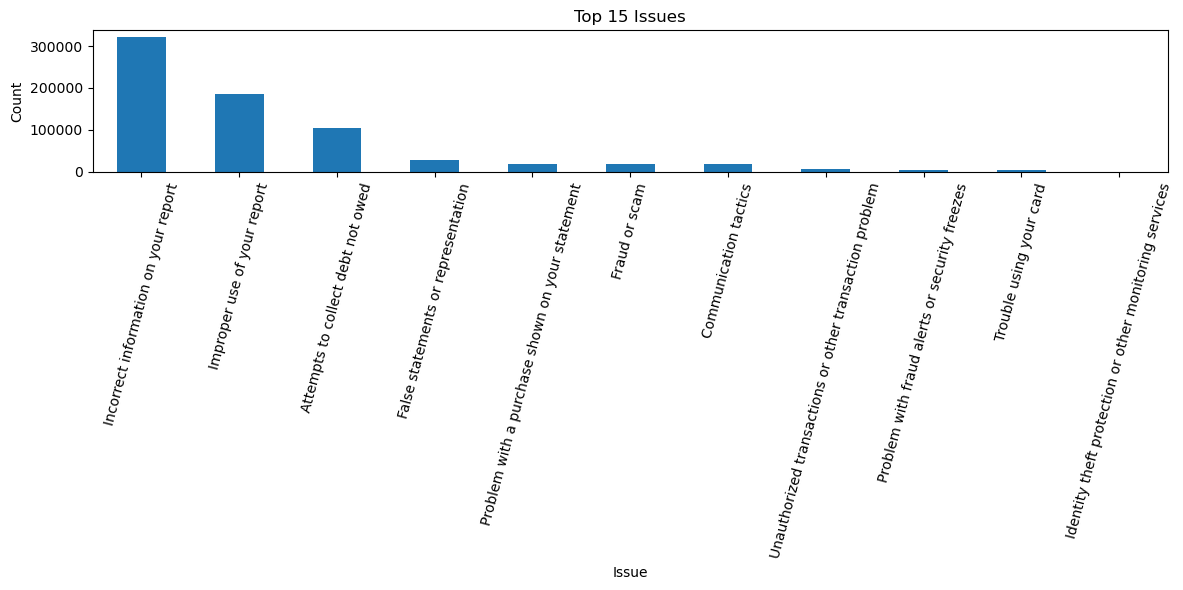

In [10]:
#Plot top issues
df['Issue'].value_counts().head(15).plot(kind='bar', figsize=(12, 6))
plt.title("Top 15 Issues")
plt.xlabel("Issue")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [11]:
#Create text length feature
df['text_length'] = df['Consumer complaint narrative'].str.len()
df[['Consumer complaint narrative', 'text_length']].head()

,Consumer complaint narrative,text_length
0,Kindly address this issue on my credit report....,210
1,Urgent : Disputed Inquiries on Credit Report -...,2153
2,This is XXXX XXXX do not deny my complaint by ...,334
3,National credit adjusters after giving then po...,313
4,"XXXX 2021, amount of XXXX to collect is Not ac...",258


In [12]:
#Text length summary stats
df['text_length'].describe()

count    708603.000000
mean       1242.316094
std        1548.141554
min          21.000000
25%         416.000000
50%         852.000000
75%        1567.000000
max       35722.000000
Name: text_length, dtype: float64

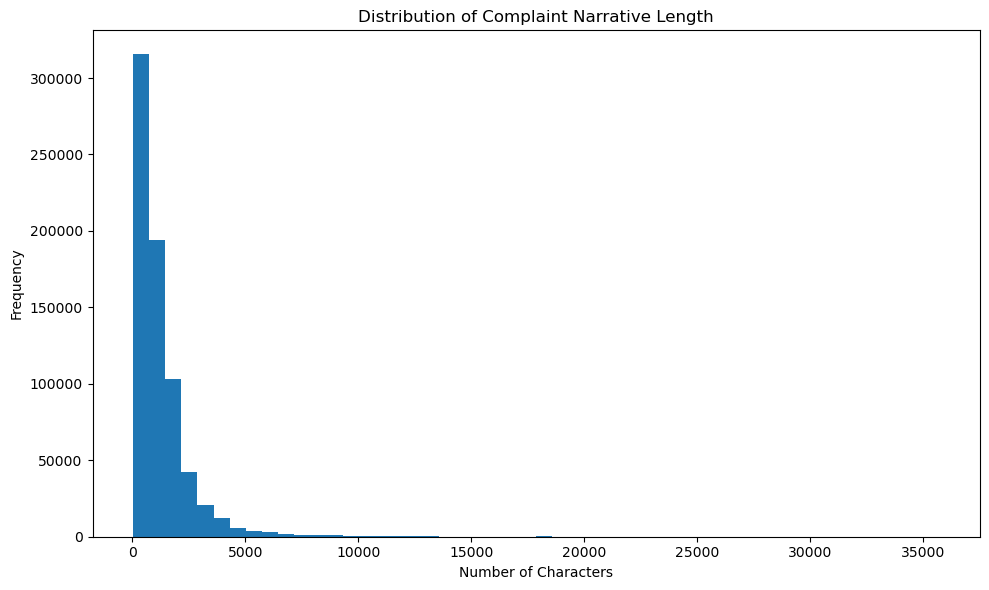

In [13]:
#Plot text length distribution
df['text_length'].plot(kind='hist', bins=50, figsize=(10, 6))
plt.title("Distribution of Complaint Narrative Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [14]:
#Average text length by label
df.groupby('label')['text_length'].mean().sort_values(ascending=False)

label
transaction_issue    1507.232170
fraud                1288.699255
credit_issue         1286.246059
scam                 1104.396096
security_issue       1095.857402
debt_fraud           1028.502731
identity_theft        918.500000
Name: text_length, dtype: float64

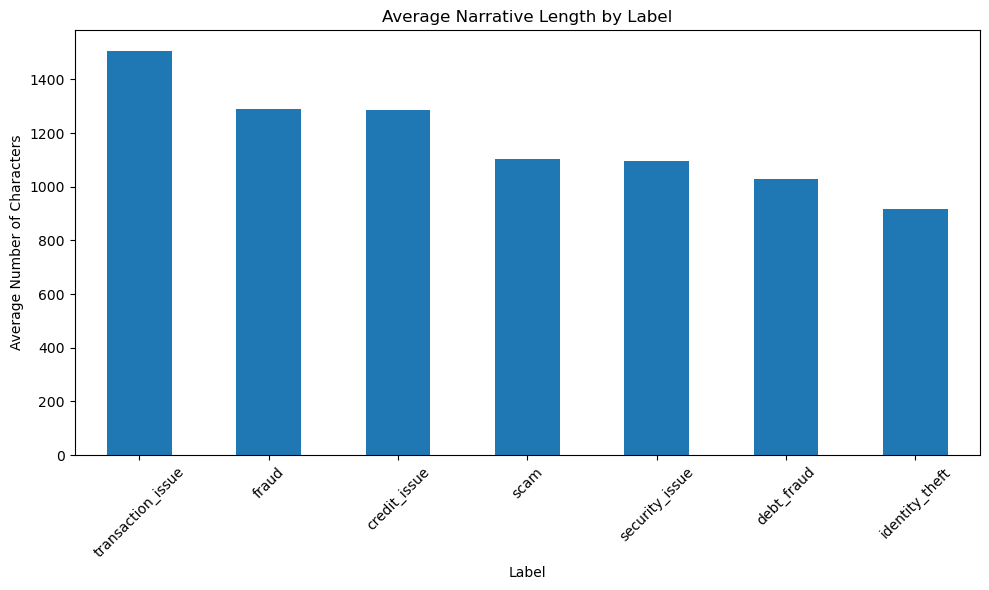

In [15]:
#Plot average text length by label
df.groupby('label')['text_length'].mean().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10, 6)
)
plt.title("Average Narrative Length by Label")
plt.xlabel("Label")
plt.ylabel("Average Number of Characters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
#Median text length by label
df.groupby('label')['text_length'].median().sort_values(ascending=False)

label
transaction_issue    1161.0
credit_issue          897.0
fraud                 888.0
security_issue        771.0
scam                  757.0
debt_fraud            647.0
identity_theft        509.5
Name: text_length, dtype: float64

In [19]:
# Complaints over time

df['Date received'] = pd.to_datetime(
    df['Date received'],
    format='%m/%d/%y',
    errors='coerce'
)

df['year'] = df['Date received'].dt.year
df['month'] = df['Date received'].dt.to_period('M')

print(df[['Date received', 'year', 'month']].head())

  Date received  year    month
0    2024-01-05  2024  2024-01
1    2024-01-28  2024  2024-01
2    2023-12-08  2023  2023-12
3    2019-04-23  2019  2019-04
4    2023-12-28  2023  2023-12


In [20]:
#Year distribution
df['year'].value_counts().sort_index()

year
2019     13731
2020     15382
2021     20656
2022     19997
2023     70574
2024    247316
2025    313877
2026      7070
Name: count, dtype: int64

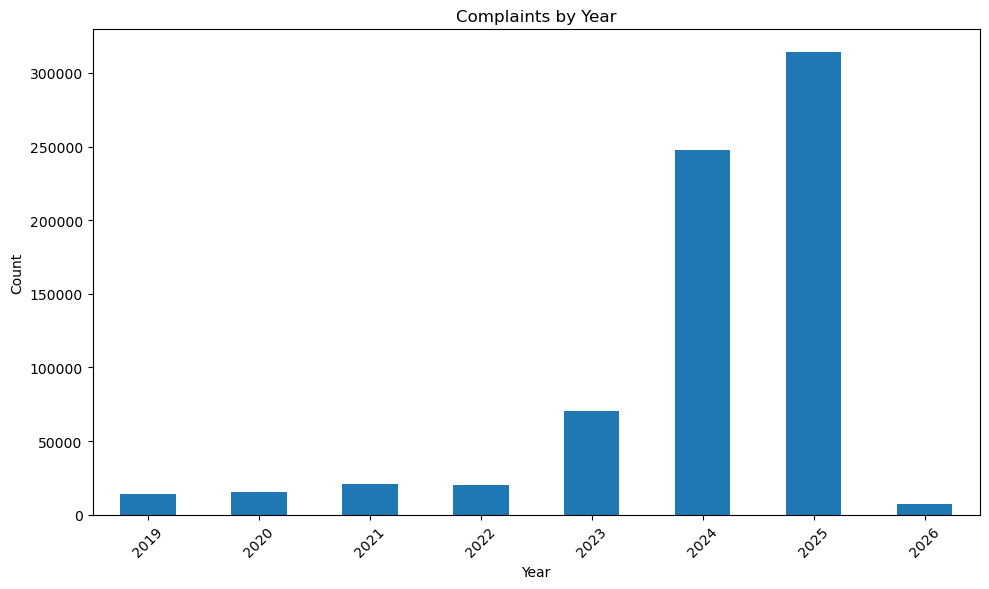

In [21]:
#Plot complaints by year
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(10, 6))
plt.title("Complaints by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
#Monthly trend
monthly_counts = df['month'].value_counts().sort_index()
monthly_counts.tail(24)

month
2024-04    18512
2024-05    19812
2024-06    19818
2024-07    21599
2024-08    22938
2024-09    22516
2024-10    23908
2024-11    23583
2024-12    25829
2025-01    36615
2025-02    21794
2025-03    24838
2025-04    24074
2025-05    26465
2025-06    32524
2025-07    35348
2025-08    30805
2025-09    23189
2025-10    20685
2025-11    22353
2025-12    15187
2026-01     5296
2026-02     1093
2026-03      681
Freq: M, Name: count, dtype: int64

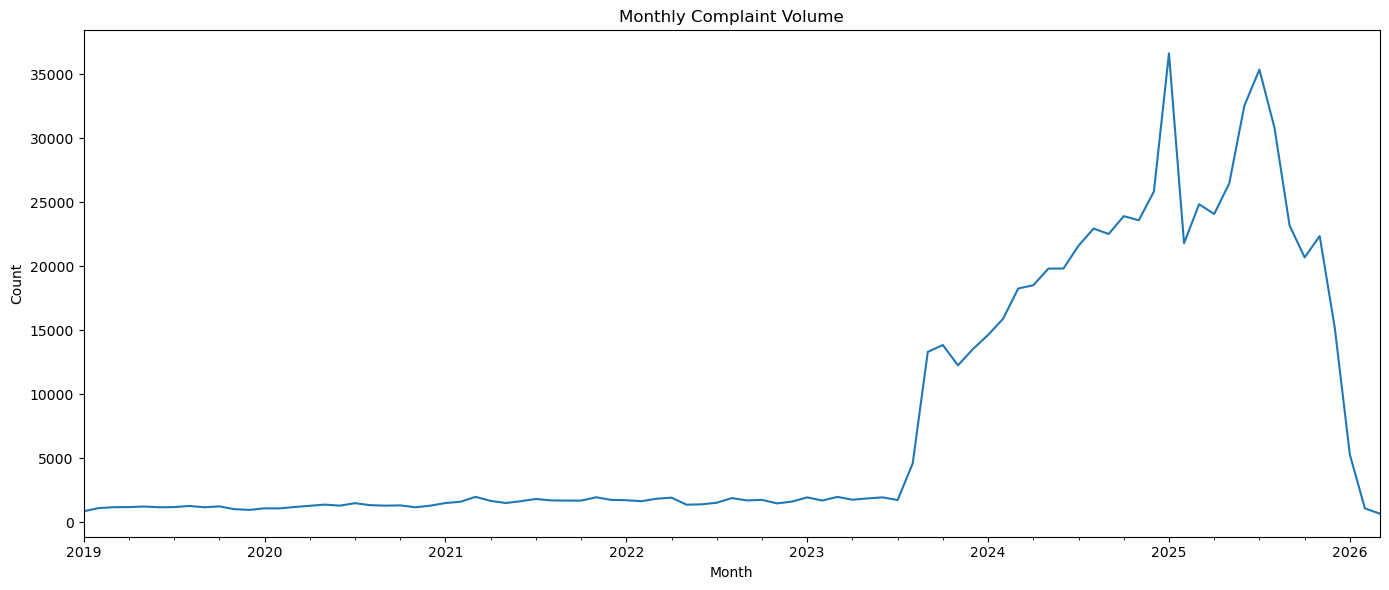

In [23]:
#Plot monthly trend
monthly_counts.plot(figsize=(14, 6))
plt.title("Monthly Complaint Volume")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [24]:
#Cross-tab: label vs product
pd.crosstab(df['label'], df['Product'])

Product,Checking or savings account,Credit card,Credit reporting or other personal consumer reports,Debt collection,"Money transfer, virtual currency, or money service",Mortgage,Student loan
label,,,,,,,
credit_issue,309,4099,498286,0,0,1794,2313
debt_fraud,0,0,0,103618,0,0,0
fraud,0,0,0,0,24958,0,0
identity_theft,0,0,472,0,0,0,0
scam,0,0,0,46105,0,0,0
security_issue,86,77,4172,0,0,25,51
transaction_issue,0,22238,0,0,0,0,0


In [25]:
#Normalized cross-tab: label vs product
pd.crosstab(df['label'], df['Product'], normalize='index')

Product,Checking or savings account,Credit card,Credit reporting or other personal consumer reports,Debt collection,"Money transfer, virtual currency, or money service",Mortgage,Student loan
label,,,,,,,
credit_issue,0.000610,0.008088,0.983199,0.0,0.0,0.003540,0.004564
debt_fraud,0.000000,0.000000,0.000000,1.0,0.0,0.000000,0.000000
fraud,0.000000,0.000000,0.000000,0.0,1.0,0.000000,0.000000
identity_theft,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.000000
scam,0.000000,0.000000,0.000000,1.0,0.0,0.000000,0.000000
security_issue,0.019497,0.017456,0.945817,0.0,0.0,0.005668,0.011562
transaction_issue,0.000000,1.000000,0.000000,0.0,0.0,0.000000,0.000000


In [26]:
#Count unique values
print("Unique labels:", df['label'].nunique())
print("Unique products:", df['Product'].nunique())
print("Unique states:", df['State'].nunique())
print("Unique issues:", df['Issue'].nunique())
print("Unique sub-issues:", df['Sub-issue'].nunique())

Unique labels: 7
Unique products: 7
Unique states: 61
Unique issues: 11
Unique sub-issues: 37


In [27]:
#Check duplicate narratives
df['Consumer complaint narrative'].duplicated().sum()

0

In [28]:
#Complaint counts by label percentage
label_pct = df['label'].value_counts(normalize=True) * 100
print(label_pct.round(2))

label
credit_issue         71.52
debt_fraud           14.62
scam                  6.51
fraud                 3.52
transaction_issue     3.14
security_issue        0.62
identity_theft        0.07
Name: proportion, dtype: float64


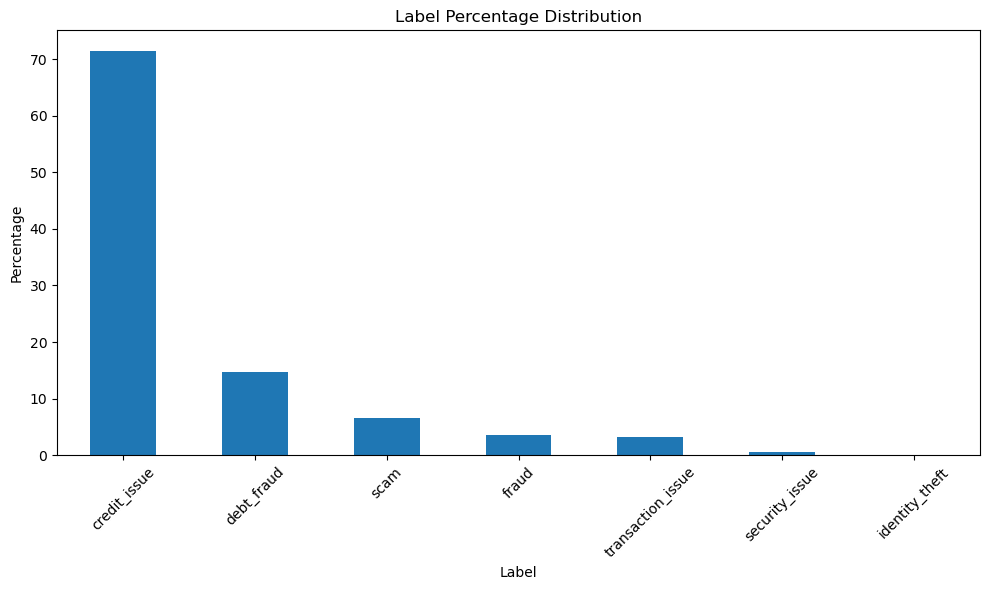

In [29]:
#Plot label percentages
label_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Label Percentage Distribution")
plt.xlabel("Label")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
#Save EDA-ready file with text_length/year/month
df.to_parquet("cfpb_eda_ready.parquet", index=False)
print("Saved: cfpb_eda_ready.parquet")

Saved: cfpb_eda_ready.parquet
